<a href="https://colab.research.google.com/github/sadia1009/conservation-reserve-selection/blob/main/Conserve_reserve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pulp

Status: Optimal
Units selected: [7, 23, 26, 31]
Total cost: 9.0


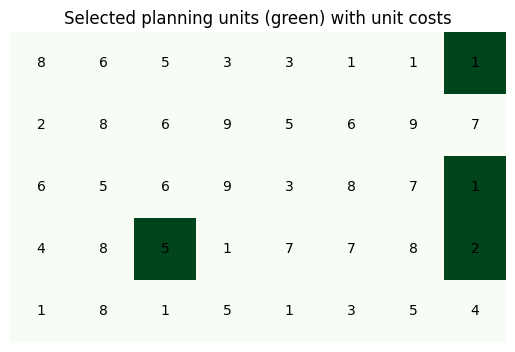

In [2]:
import numpy as np
import pulp
import matplotlib.pyplot as plt

# --- Made-up data: a 5x8 grid of planning units ---
rng = np.random.default_rng(0)
rows, cols = 5, 8
n_units, n_feat = rows * cols, 12
cost = rng.integers(1, 10, n_units)
presence = rng.random((n_units, n_feat)) < 0.2

# make sure every feature occurs in at least one unit
for j in range(n_feat):
    if not presence[:, j].any():
        presence[rng.integers(n_units), j] = True

# --- Model: cover every feature at minimum cost ---
prob = pulp.LpProblem("reserve_selection", pulp.LpMinimize)
x = [pulp.LpVariable(f"x{i}", cat="Binary") for i in range(n_units)]

prob += pulp.lpSum(cost[i] * x[i] for i in range(n_units))
for j in range(n_feat):
    prob += pulp.lpSum(x[i] for i in range(n_units) if presence[i, j]) >= 1

prob.solve(pulp.PULP_CBC_CMD(msg=0))
chosen = [i for i in range(n_units) if x[i].value() == 1]
print("Status:", pulp.LpStatus[prob.status])
print("Units selected:", chosen)
print("Total cost:", pulp.value(prob.objective))

# --- Results figure ---
grid = np.zeros(n_units)
grid[chosen] = 1
plt.imshow(grid.reshape(rows, cols), cmap="Greens")
for i in range(n_units):
    plt.text(i % cols, i // cols, cost[i], ha="center", va="center")
plt.title("Selected planning units (green) with unit costs")
plt.axis("off")
plt.savefig("results.png", dpi=200, bbox_inches="tight")
plt.show()